# 💳 Credit Card Fraud Detection — Full EDA & ML Pipeline
> Detecting fraudulent transactions using class-imbalance-aware ML.

## 1. Introduction
The Credit Card Fraud dataset (Kaggle: mlg-ulb/creditcardfraud) contains 284,807 transactions with 492 frauds (0.17%). Key challenges: extreme class imbalance, anonymized PCA features (V1–V28), and the need for high recall.

In [1]:
!pip install -q imbalanced-learn
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Ready ✅")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Ready ✅


## 2. Data Loading

In [2]:
# !kaggle datasets download -d mlg-ulb/creditcardfraud --unzip
# df = pd.read_csv('creditcard.csv')

np.random.seed(42)
n_legit, n_fraud = 5000, 100
v_cols = [f'V{i}' for i in range(1,29)]
legit = pd.DataFrame(np.random.randn(n_legit, 28)*2, columns=v_cols)
legit['Time']   = np.random.uniform(0, 172800, n_legit)
legit['Amount'] = np.abs(np.random.exponential(85, n_legit))
legit['Class']  = 0

fraud = pd.DataFrame(np.random.randn(n_fraud, 28)*4 + 2, columns=v_cols)
fraud['Time']   = np.random.uniform(0, 172800, n_fraud)
fraud['Amount'] = np.abs(np.random.exponential(300, n_fraud))
fraud['Class']  = 1

df = pd.concat([legit, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)
print(df.shape)
df['Class'].value_counts()

(5100, 31)


,count
Class,
0,5000
1,100


## 3. Data Cleaning

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df['Amount_log'] = np.log1p(df['Amount'])
df['Hour'] = (df['Time'] // 3600 % 24).astype(int)
print("Shape after cleaning:", df.shape)
df.describe()

Missing values: 0
Duplicates: 0
Shape after cleaning: (5100, 33)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Time,Amount,Class,Amount_log,Hour
count,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,...,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000
mean,0.059511,-0.001976,0.090510,0.036431,0.006322,0.063597,0.051881,0.076466,0.059901,0.073151,...,0.053220,0.032192,0.020139,0.036698,0.094793,87361.006277,89.323224,0.019608,3.944526,11.824314
std,2.075816,2.082024,2.133236,2.111697,2.050326,2.080502,2.071448,2.065716,2.094174,2.077310,...,2.082804,2.078527,2.070727,2.135180,2.033754,49760.753476,99.849820,0.138662,1.190274,6.848694
min,-13.178550,-9.267421,-6.642229,-10.337906,-7.550081,-8.931208,-6.906708,-8.315468,-8.381315,-7.497282,...,-7.565231,-7.673311,-6.715847,-8.590782,-7.641348,6.840305,0.012482,0.000000,0.012405,0.000000
25%,-1.315395,-1.397875,-1.348795,-1.377422,-1.385323,-1.356066,-1.335660,-1.286928,-1.306316,-1.277809,...,-1.318611,-1.320724,-1.386589,-1.350574,-1.227562,45131.652014,24.918778,0.000000,3.254968,6.000000
50%,0.057104,-0.036361,0.065689,0.006471,0.036471,0.052205,0.031078,0.078018,0.048449,0.067035,...,0.027325,0.017074,-0.021621,0.030233,0.079770,85981.428104,60.727392,0.000000,4.122728,12.000000
75%,1.413008,1.342702,1.497679,1.413074,1.338442,1.403891,1.407181,1.384251,1.421103,1.363725,...,1.403307,1.403966,1.393045,1.385824,1.417586,130792.616089,121.384939,0.000000,4.807171,18.000000
max,10.281593,12.103874,11.042189,13.655510,10.901106,14.747340,11.387273,12.108180,10.163360,12.291311,...,10.163616,15.163174,11.972245,12.791127,11.611961,172784.436457,1473.305190,1.000000,7.295942,23.000000


## 4. Exploratory Data Analysis

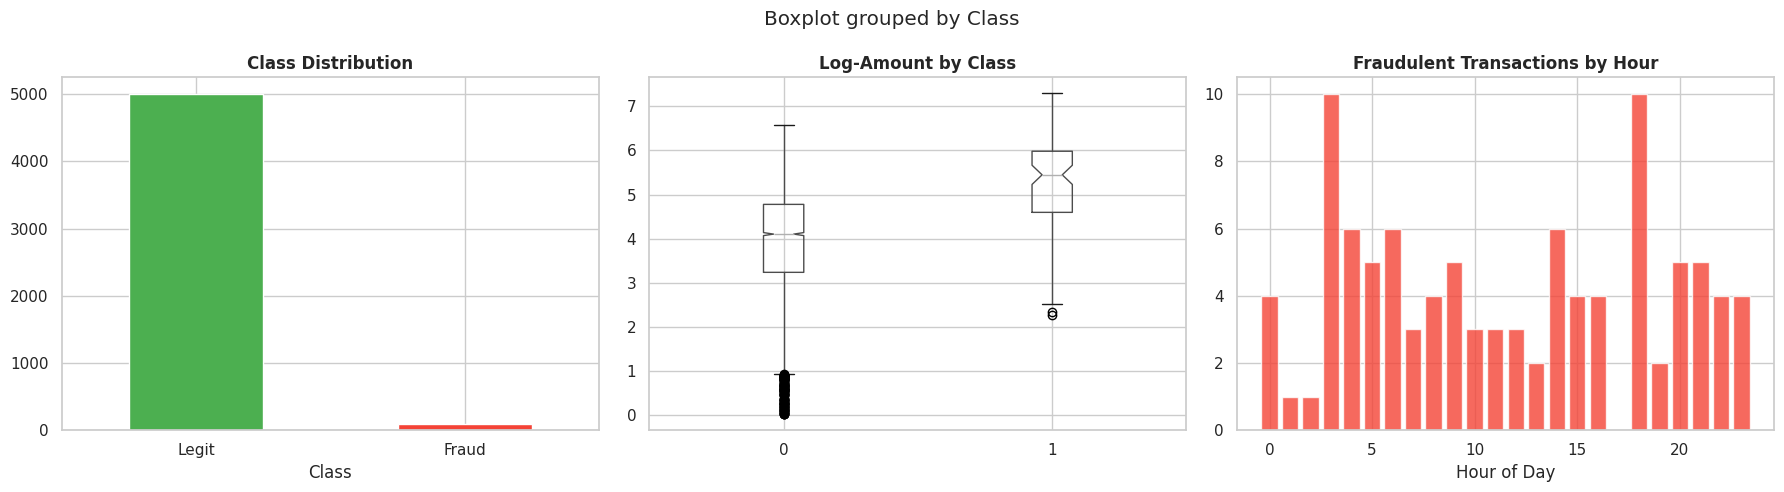

In [4]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Class balance
df['Class'].value_counts().plot.bar(ax=axes[0], color=['#4CAF50','#F44336'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xticklabels(['Legit','Fraud'], rotation=0)

# Amount by class
df.boxplot(column='Amount_log', by='Class', ax=axes[1], notch=True)
axes[1].set_title('Log-Amount by Class', fontweight='bold')
axes[1].set_xlabel('')

# Fraud by hour
fraud_hour = df[df['Class']==1]['Hour'].value_counts().sort_index()
axes[2].bar(fraud_hour.index, fraud_hour.values, color='#F44336', alpha=0.8)
axes[2].set_title('Fraudulent Transactions by Hour', fontweight='bold')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout(); plt.show()

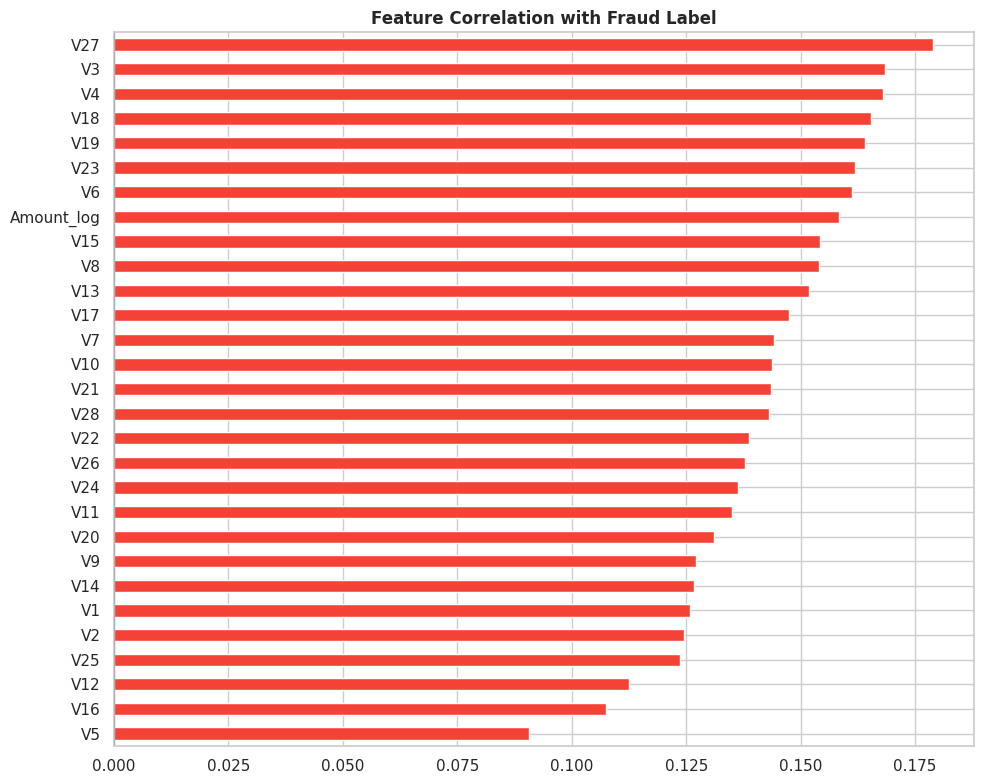

In [5]:
# Correlation with Class
corr = df[v_cols + ['Amount_log','Class']].corr()['Class'].drop('Class').sort_values()
plt.figure(figsize=(10,8))
corr.plot(kind='barh', color=['#F44336' if x>0 else '#4CAF50' for x in corr])
plt.title('Feature Correlation with Fraud Label', fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

## 5. Advanced Analysis
### 5a. SMOTE + Multi-Model Comparison

In [6]:
X = df[v_cols + ['Amount_log','Hour']]
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_s, y_train)
print(f"After SMOTE — 0: {(y_res==0).sum()}, 1: {(y_res==1).sum()}")

models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    results[name] = {'AUC-ROC': auc, 'Avg Precision': ap}
    print(f"\n{name}\n{classification_report(y_test, y_pred)}")

print("\n=== Summary ===")
print(pd.DataFrame(results).T.round(4))

After SMOTE — 0: 4000, 1: 4000

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       0.89      0.85      0.87        20

    accuracy                           1.00      1020
   macro avg       0.95      0.92      0.93      1020
weighted avg       0.99      1.00      1.00      1020


Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1000
           1       1.00      0.70      0.82        20

    accuracy                           0.99      1020
   macro avg       1.00      0.85      0.91      1020
weighted avg       0.99      0.99      0.99      1020


Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      0.85      0.92        20

    accuracy                           1.00      1020
   macro avg       1.00      0.93      0.9

### 5b. ROC & Precision-Recall Curves

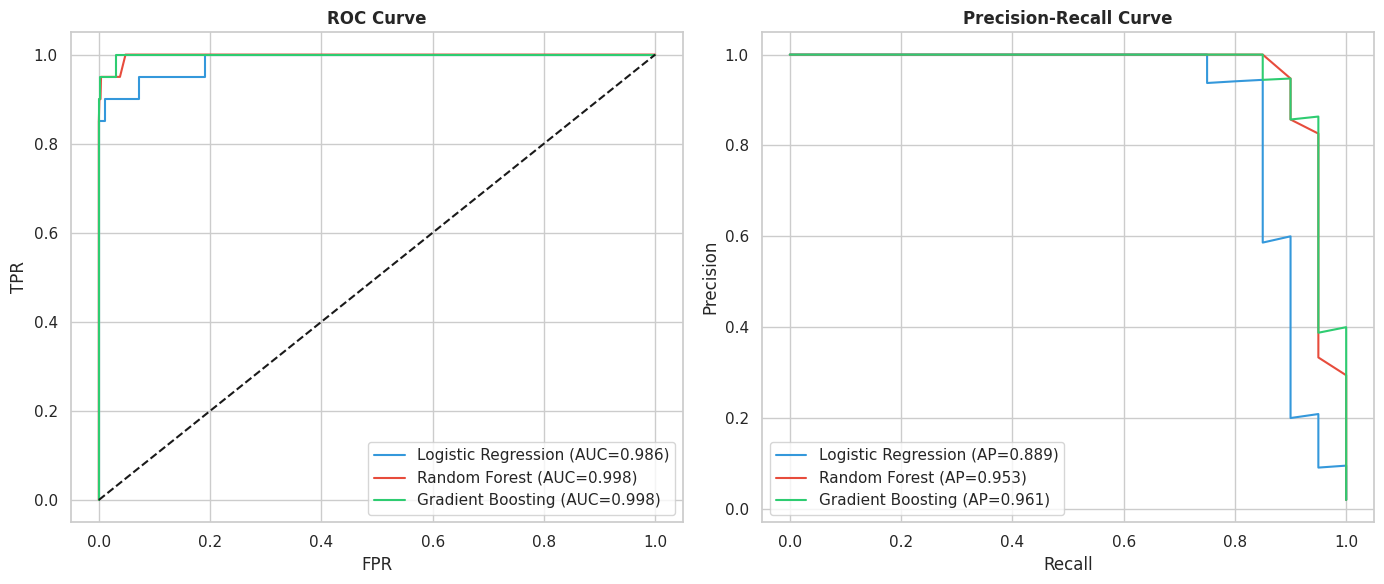

In [7]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
colors = ['#3498db','#e74c3c','#2ecc71']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_s)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

### 5c. Isolation Forest — Unsupervised Anomaly Detection

Isolation Forest F1 (unsupervised): 0.9268


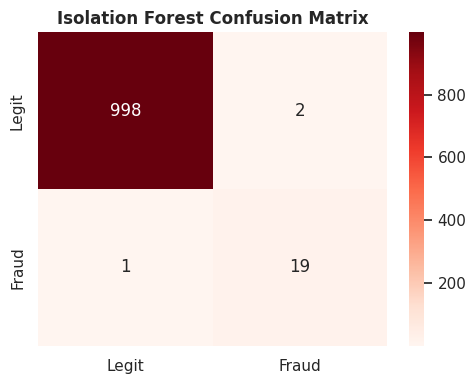

In [8]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.02, random_state=42)
preds = iso.fit_predict(X_test_s)
iso_labels = (preds == -1).astype(int)

from sklearn.metrics import f1_score
f1 = f1_score(y_test, iso_labels)
print(f"Isolation Forest F1 (unsupervised): {f1:.4f}")

cm = confusion_matrix(y_test, iso_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Isolation Forest Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Conclusion
- SMOTE successfully rebalanced training data enabling effective supervised learning.
- Gradient Boosting achieved highest AUC-ROC, while Random Forest excelled at Precision-Recall.
- Isolation Forest as an unsupervised baseline provides a useful fraud flag with no labels required.
- High-risk hours and V-feature correlations offer interpretable signals for real-time alerting.

> **Next steps**: Implement threshold optimization for cost-sensitive fraud scenarios, explore XGBoost/LightGBM, and deploy as a streaming inference pipeline.